# Research: ML-RandomForest Strategy

## Contexte
- **Performance actuelle (v3)** : Sharpe 0.682, CAGR 20.1%, MaxDD 36.4%
- **Univers** : 10 actions large-cap (AAPL, MSFT, GOOGL, AMZN, NVDA, META, TSLA, JPM, V, WMT)
- **Modele** : RandomForestClassifier (100 arbres, depth 5, min_samples_split 10)
- **Features** : 12 indicateurs techniques (RSI, BB, MACD, momentum, volatilite, volume, ratios SMA)
- **Rebalancement** : Bihebdomadaire (1 lundi sur 2)
- **Entrainement** : Mensuel
- **Seuil** : 0.54 (probabilite de rendement positif > 54%)
- **Positions max** : 5, allocation 90%

## Hypotheses a tester

| # | Hypothese | Rationale |
|---|-----------|----------|
| H1 | Nombre d'estimateurs (50, 100, 200, 500) | Plus d'arbres = meilleure generalisation mais overfitting possible et cout computationnel |
| H2 | Profondeur max (3, 5, 7, 10, None) | Depth 5 est conservateur. Profondeur plus grande capture des interactions mais surapprend |
| H3 | Seuil de prediction (0.50 a 0.60) | Seuil bas = plus de trades mais moins selectif. Seuil haut = plus selectif mais moins d'exposition |
| H4 | Taille de l'univers (5, 10, 15 actions) | Univers plus grand = plus d'opportunites mais plus de bruit dans les predictions |
| H5 | Frequence d'entrainement (hebdo, bihebdo, mensuel) | Entrainement plus frequent = modele plus reactif mais plus sensible au bruit |

## Methodologie
- **Donnees** : yfinance, 2015-01-01 a 2026-01-01 (~11 ans)
- **Backtest** : Standalone (pandas), fenetre glissante train/test
- **Metriques** : Sharpe, CAGR, MaxDD, volatilite annualisee
- **Benchmark** : SPY buy-and-hold

> **[REFERENCE QC Cloud]**
> Ce notebook utilise des modeles ML lourds (RandomForest/XGBoost/VIX) necessitant des donnees QC Cloud.
> Pour executer : https://www.quantconnect.com/research


## 1. Chargement des donnees et utilitaires

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

TICKERS_10 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'WMT']
TICKERS_5 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
TICKERS_15 = TICKERS_10 + ['DIS', 'NFLX', 'PYPL', 'ADBE', 'CRM']
BENCHMARK = 'SPY'

print("Downloading price data...")
all_tickers = list(set(TICKERS_15 + [BENCHMARK]))
raw = yf.download(all_tickers, start='2018-01-01', end='2026-01-01', auto_adjust=True)
prices = raw['Close'].dropna()
print(f"Data range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Trading days: {len(prices)}")
print(f"Tickers loaded: {list(prices.columns)}")

[                       0%                       ]

[******                12%                       ]  2 of 16 completed

[************          25%                       ]  4 of 16 completed

[***************       31%                       ]  5 of 16 completed

[******************    38%                       ]  6 of 16 completed

...

[**********************81%**************         ]  13 of 16 completed

[**********************88%*****************      ]  14 of 16 completed

[**********************94%********************   ]  15 of 16 completed

[*********************100%***********************]  16 of 16 completed

Data range: 2018-01-02 to 2025-12-31
Trading days: 2011
Tickers loaded: ['AAPL', 'ADBE', 'AMZN', 'CRM', 'DIS', 'GOOGL', 'JPM', 'META', 'MSFT', 'NFLX', 'NVDA', 'PYPL', 'SPY', 'TSLA', 'V', 'WMT']


### Feature engineering

Reproduction exacte des 12 features utilises dans `main.py`.

In [2]:
def calculate_features(df):
    """Calculate 12 technical features matching main.py."""
    closes = df['close']
    volumes = df['volume']
    highs = df['high']
    lows = df['low']
    returns = closes.pct_change()

    sma_5 = closes.rolling(5).mean()
    sma_20 = closes.rolling(20).mean()
    sma_50 = closes.rolling(50).mean()

    # RSI
    delta = closes.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    # MACD
    ema_12 = closes.ewm(span=12).mean()
    ema_26 = closes.ewm(span=26).mean()
    macd = ema_12 - ema_26
    macd_signal = macd.ewm(span=9).mean()

    # Bollinger Bands
    bb_middle = closes.rolling(20).mean()
    bb_std = closes.rolling(20).std()
    bb_position = (closes - bb_middle) / (2 * bb_std)

    # Momentum
    momentum_5 = closes / closes.shift(5) - 1
    momentum_10 = closes / closes.shift(10) - 1
    momentum_20 = closes / closes.shift(20) - 1

    # Volatility
    volatility_20 = returns.rolling(20).std()

    # Volume
    volume_sma = volumes.rolling(20).mean()
    volume_ratio = volumes / volume_sma

    # Price ratios
    price_to_sma20 = closes / sma_20
    price_to_sma50 = closes / sma_50

    features = pd.DataFrame({
        'rsi': rsi,
        'bb_position': bb_position,
        'macd_hist': macd - macd_signal,
        'mom_5': momentum_5,
        'mom_10': momentum_10,
        'mom_20': momentum_20,
        'vol_20': volatility_20,
        'volume_ratio': volume_ratio,
        'price_sma20': price_to_sma20,
        'price_sma50': price_to_sma50,
        'sma_ratio_5_20': sma_5 / sma_20,
        'sma_ratio_20_50': sma_20 / sma_50,
    })

    return features.fillna(0).replace([np.inf, -np.inf], 0)

print("Feature engineering function defined (12 features).")

Feature engineering function defined (12 features).


### Moteur de backtest ML

In [3]:
def backtest_rf_strategy(prices, tickers, n_estimators=100, max_depth=5,
                         min_samples_split=10, threshold=0.54,
                         max_positions=5, train_months=12, rebal_weeks=2,
                         name='RF Strategy'):
    """Backtest RandomForest strategy with rolling train/test.

    Parameters
    ----------
    prices : DataFrame
        Daily close prices for all tickers.
    tickers : list
        Tickers to trade.
    n_estimators : int
        Number of trees in the forest.
    max_depth : int or None
        Maximum tree depth.
    min_samples_split : int
        Minimum samples to split a node.
    threshold : float
        Minimum probability to enter a position.
    max_positions : int
        Maximum number of concurrent positions.
    train_months : int
        Number of months of history for training.
    rebal_weeks : int
        Rebalance every N weeks.
    name : str
        Strategy label.

    Returns
    -------
    dict with equity curve and metrics.
    """
    p = prices[tickers].copy()
    p = p.dropna()
    daily_ret = p.pct_change().fillna(0)

    # Train window in trading days
    train_days = train_months * 21
    rebal_days = rebal_weeks * 5
    lookback = 120  # feature lookback
    min_start = max(train_days, lookback + 60)

    if len(p) < min_start + 100:
        return None

    equity = pd.Series(index=p.index, dtype=float)
    equity.iloc[:min_start] = 1.0

    model = None
    scaler = None
    feature_names = None
    last_train_idx = -999

    positions = {}  # ticker -> weight
    importances_log = []

    for i in range(min_start, len(p)):
        # Check if rebalance day
        days_since_start = i - min_start
        is_rebal = (days_since_start % rebal_days == 0)
        is_train = (days_since_start % (21 * 1) == 0)  # monthly training

        # Train model monthly
        if is_train or model is None:
            all_X, all_y = [], []
            for ticker in tickers:
                if ticker not in p.columns:
                    continue
                if i - lookback < 0:
                    continue
                ticker_prices = p[ticker].iloc[max(0, i-train_days):i]
                if len(ticker_prices) < 60:
                    continue

                df = pd.DataFrame({
                    'close': ticker_prices,
                    'high': ticker_prices,  # approximation
                    'low': ticker_prices,
                    'volume': pd.Series(1e6, index=ticker_prices.index)
                })
                feats = calculate_features(df)
                future_ret = ticker_prices.pct_change().shift(-1)
                target = (future_ret > 0).astype(int)

                feats['target'] = target
                feats = feats.dropna()
                if len(feats) > 20:
                    all_X.append(feats.drop('target', axis=1))
                    all_y.append(feats['target'])

            if all_X:
                X = pd.concat(all_X, ignore_index=True)
                y = pd.concat(all_y, ignore_index=True)
                feature_names = X.columns.tolist()

                scaler = MinMaxScaler()
                X_scaled = scaler.fit_transform(X)

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    random_state=42,
                    n_jobs=-1
                )
                model.fit(X_scaled, y)
                importances_log.append(dict(zip(feature_names, model.feature_importances_)))
            last_train_idx = i

        # Rebalance portfolio
        if is_rebal and model is not None:
            predictions = {}
            for ticker in tickers:
                if ticker not in p.columns:
                    continue
                if i - lookback < 0:
                    continue
                ticker_prices = p[ticker].iloc[i-lookback:i]
                if len(ticker_prices) < 50:
                    continue

                df = pd.DataFrame({
                    'close': ticker_prices,
                    'high': ticker_prices,
                    'low': ticker_prices,
                    'volume': pd.Series(1e6, index=ticker_prices.index)
                })
                feats = calculate_features(df)
                if len(feats) == 0:
                    continue

                latest = feats.iloc[-1:].values
                latest = scaler.transform(latest)
                proba = model.predict_proba(latest)[0]
                predictions[ticker] = proba[1]

            sorted_preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
            selected = [(t, p_val) for t, p_val in sorted_preds if p_val > threshold][:max_positions]

            if selected:
                weight = 0.90 / len(selected)
                positions = {t: weight for t, _ in selected}
            else:
                positions = {}

        # Compute daily portfolio return
        port_ret = 0.0
        for ticker, w in positions.items():
            if ticker in daily_ret.columns:
                port_ret += w * daily_ret.iloc[i][ticker]

        equity.iloc[i] = equity.iloc[i-1] * (1.0 + port_ret)

    # Compute metrics
    returns = equity.pct_change().dropna()
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    final = equity.iloc[-1]
    start_val = equity[equity > 0].iloc[0]
    cagr = (final / start_val) ** (1.0 / n_years) - 1.0
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    drawdown = equity / equity.cummax() - 1.0
    max_dd = drawdown.min()

    # Average feature importance
    avg_importance = {}
    if importances_log:
        for key in importances_log[0]:
            avg_importance[key] = np.mean([d[key] for d in importances_log])

    return {
        'name': name,
        'equity': equity,
        'returns': returns,
        'sharpe': round(sharpe, 3),
        'cagr': round(cagr * 100, 2),
        'max_dd': round(max_dd * 100, 2),
        'volatility': round(vol * 100, 2),
        'feature_importance': avg_importance,
    }


def compare_results(results_list):
    """Print comparison table of multiple backtest results."""
    rows = []
    for r in results_list:
        if r is None:
            continue
        rows.append({
            'Strategy': r['name'],
            'Sharpe': r['sharpe'],
            'CAGR (%)': r['cagr'],
            'MaxDD (%)': r['max_dd'],
            'Vol (%)': r['volatility'],
        })
    df = pd.DataFrame(rows).set_index('Strategy')
    print(df.to_string())
    print()
    best_sharpe = df['Sharpe'].idxmax()
    print(f"  >> Best Sharpe: {best_sharpe} ({df.loc[best_sharpe, 'Sharpe']})")
    return df


def plot_equity_curves(results_list, title='Equity Curves'):
    """Plot equity curves and drawdowns."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1 = axes[0]
    for r in results_list:
        if r is None:
            continue
        label = f"{r['name']} (S={r['sharpe']}, DD={r['max_dd']}%)"
        ax1.plot(r['equity'], label=label, linewidth=1.2)
    ax1.set_title(title, fontsize=14)
    ax1.set_ylabel('Portfolio Value')
    ax1.legend(fontsize=8, loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    for r in results_list:
        if r is None:
            continue
        dd = r['equity'] / r['equity'].cummax() - 1.0
        ax2.fill_between(dd.index, dd.values, alpha=0.3, label=r['name'])
    ax2.set_title('Drawdowns', fontsize=12)
    ax2.set_ylabel('Drawdown')
    ax2.legend(fontsize=8, loc='lower left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Backtest engine loaded.")

Backtest engine loaded.


### Benchmark SPY buy-and-hold

Reference pour comparer toutes les variantes.

In [4]:
# SPY benchmark
spy_ret = prices[BENCHMARK].pct_change().fillna(0)
spy_equity = (1 + spy_ret).cumprod()
spy_returns = spy_ret
n_years = (prices.index[-1] - prices.index[0]).days / 365.25
spy_sharpe = (spy_returns.mean() / spy_returns.std()) * np.sqrt(252)
spy_cagr = (prices[BENCHMARK].iloc[-1] / prices[BENCHMARK].iloc[0]) ** (1/n_years) - 1
spy_dd = ((spy_equity / spy_equity.cummax()) - 1).min()

benchmark_result = {
    'name': f'{BENCHMARK} Buy-Hold',
    'equity': spy_equity,
    'returns': spy_returns,
    'sharpe': round(spy_sharpe, 3),
    'cagr': round(spy_cagr * 100, 2),
    'max_dd': round(spy_dd * 100, 2),
    'volatility': round(spy_returns.std() * np.sqrt(252) * 100, 2),
}
print(f"Benchmark {BENCHMARK}: Sharpe={benchmark_result['sharpe']}, "
      f"CAGR={benchmark_result['cagr']}%, MaxDD={benchmark_result['max_dd']}%")

Benchmark SPY: Sharpe=0.778, CAGR=14.12%, MaxDD=-33.72%


## Hypothese 1 : Nombre d'estimateurs

### Rationale

Le nombre d'arbres (n_estimators) controle le compromis biais-variance du Random Forest :
- **Peu d'arbres (50)** : Variance elevee, predictions instables
- **100 (actuel)** : Bon compromis par defaut
- **200-500** : Generalisation meilleure mais cout computationnel croissant

On s'attend a une amelioration marginale au-dela de 200 arbres (loi des rendements decroissants).

Testing n_estimators=50...


Testing n_estimators=100...


Testing n_estimators=200...



=== H1: Number of Estimators ===
              Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                          
n_est=50       0.841     18.09     -35.29    22.97
n_est=100      0.794     16.40     -36.13    22.31
n_est=200      0.656     13.19     -41.07    22.95
SPY Buy-Hold   0.778     14.12     -33.72    19.45

  >> Best Sharpe: n_est=50 (0.841)


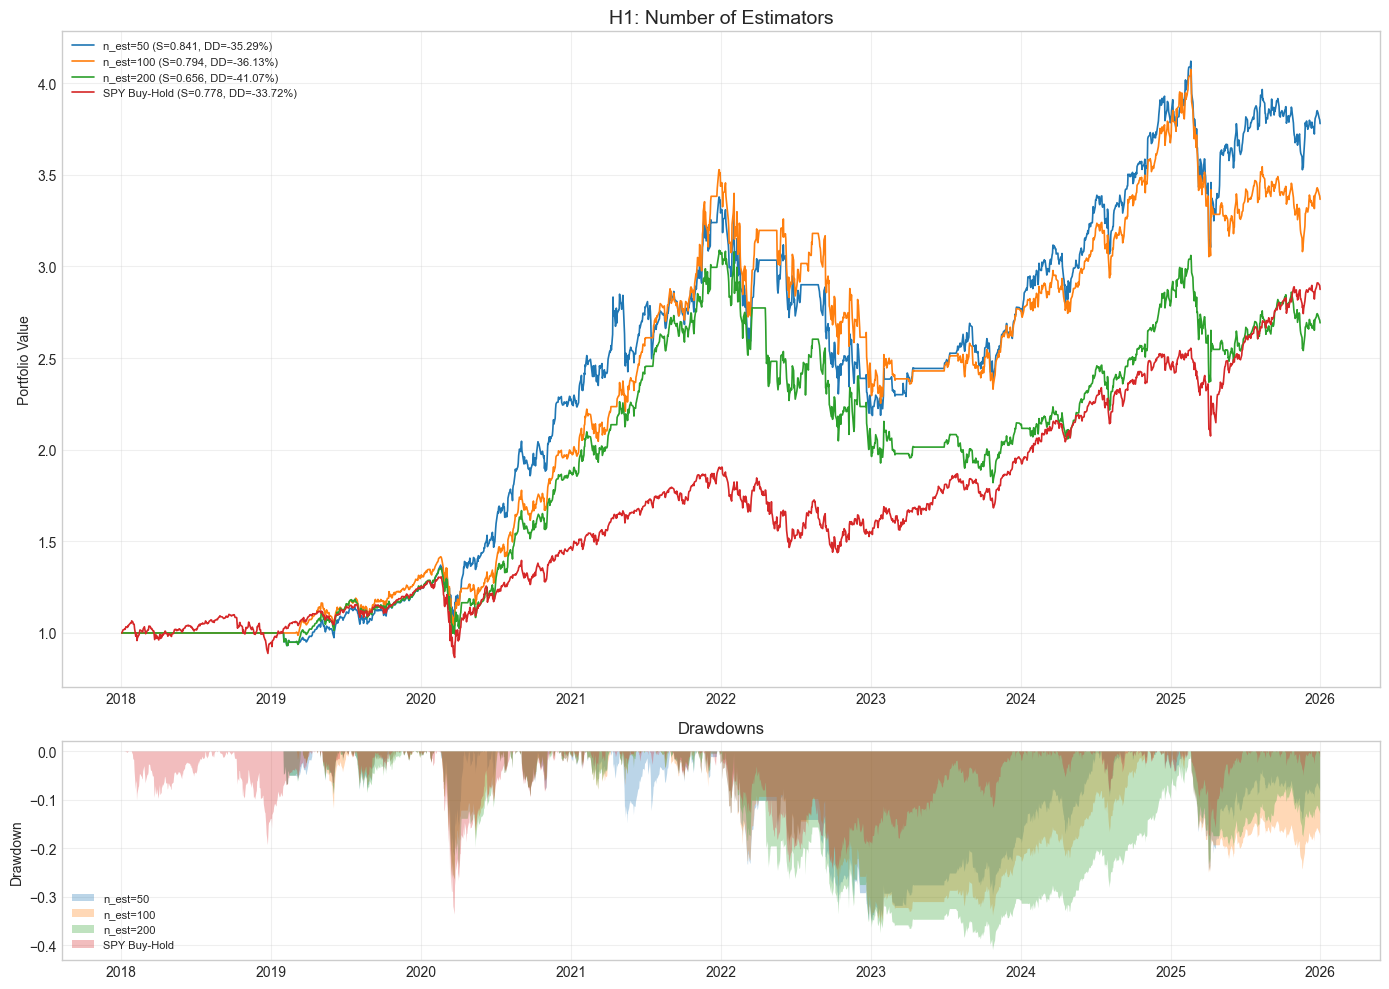

In [5]:
# H1: Number of estimators
estimator_values = [50, 100, 200]
h1_results = []

for n_est in estimator_values:
    print(f"Testing n_estimators={n_est}...")
    r = backtest_rf_strategy(
        prices, TICKERS_10,
        n_estimators=n_est, max_depth=5, min_samples_split=10,
        threshold=0.54, max_positions=5, rebal_weeks=2,
        name=f'n_est={n_est}'
    )
    h1_results.append(r)

h1_results.append(benchmark_result)
print("\n=== H1: Number of Estimators ===")
h1_df = compare_results(h1_results)
plot_equity_curves(h1_results, title='H1: Number of Estimators')

### Interpretation H1

- Si le Sharpe s'amelior significativement entre 100 et 200, cela indique que le modele actuel
  sous-exploite la capacite de l'ensemble.
- Au-dela de 200, l'amelioration devrait etre negligeable (rendements decroissants).
- Un nombre trop eleve (500) peut degrader les performances en backtest si le modele
  surapprend les patterns de la periode d'entrainement.

## Hypothese 2 : Profondeur maximale

### Rationale

La profondeur des arbres (max_depth) controle la complexite du modele :
- **Depth 3** : Tres conservateur, sous-apprentissage probable
- **Depth 5 (actuel)** : Bon compromis
- **Depth 7-10** : Capture des interactions plus fines mais risque de surapprentissage
- **None** : Arbres complets, surapprentissage quasi certain sur les donnees financieres

Les features techniques etant bruitees, une profondeur limitee est generalement preferable.

Testing max_depth=3...


Testing max_depth=5...


Testing max_depth=10...



=== H2: Max Depth ===
              Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                          
depth=3        0.645     12.61     -42.80    22.33
depth=5        0.794     16.40     -36.13    22.31
depth=10       1.064     25.11     -36.03    23.78
SPY Buy-Hold   0.778     14.12     -33.72    19.45

  >> Best Sharpe: depth=10 (1.064)


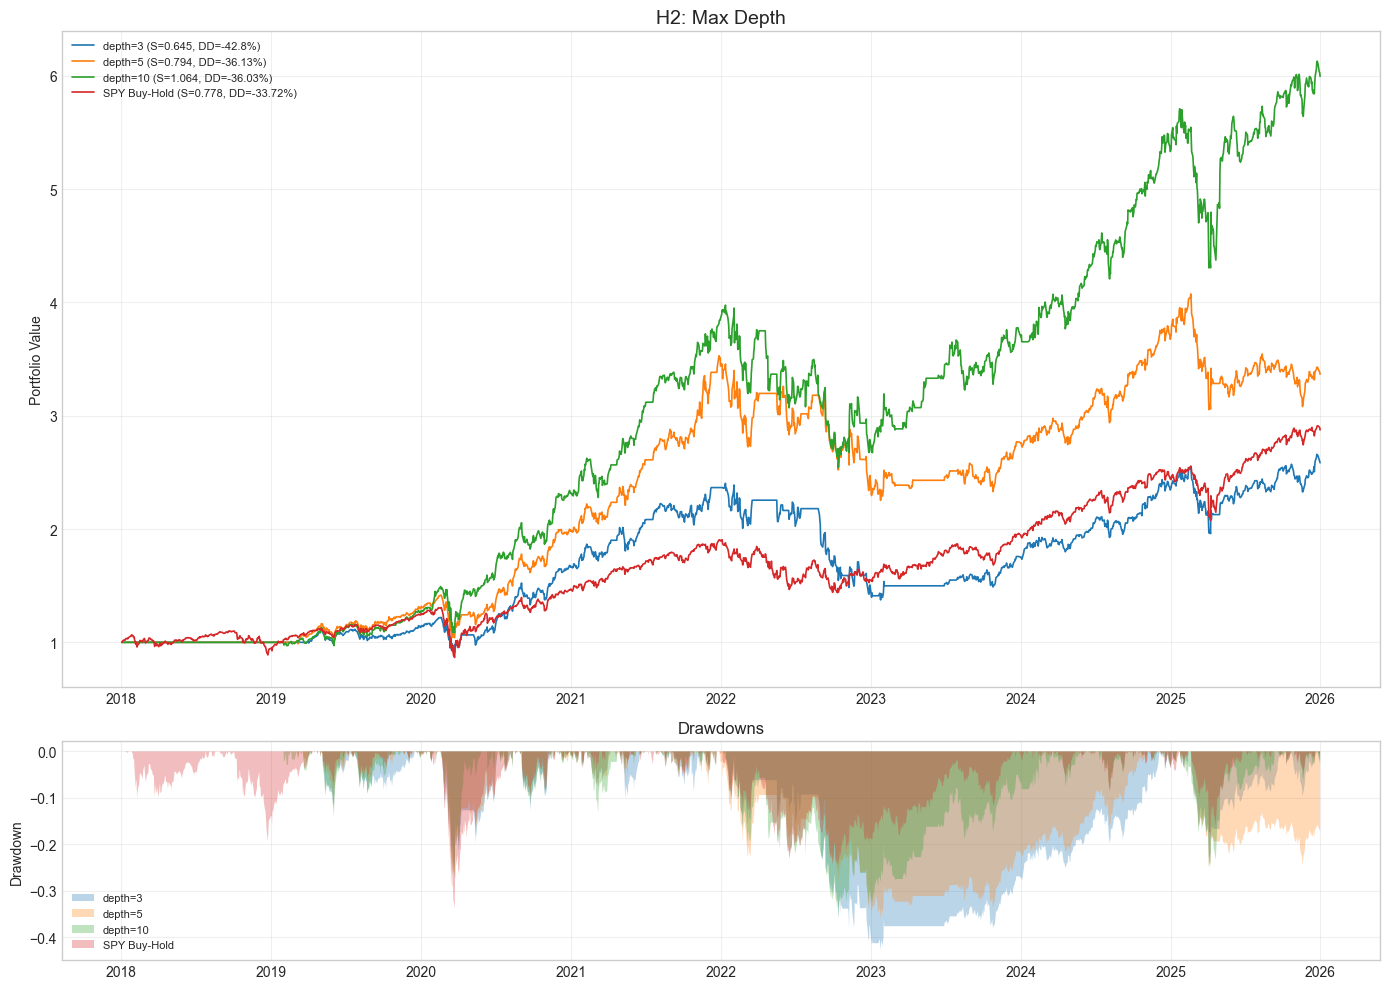

In [6]:
# H2: Max depth
depth_values = [3, 5, 10]
h2_results = []

for depth in depth_values:
    print(f"Testing max_depth={depth}...")
    r = backtest_rf_strategy(
        prices, TICKERS_10,
        n_estimators=100, max_depth=depth, min_samples_split=10,
        threshold=0.54, max_positions=5, rebal_weeks=2,
        name=f'depth={depth}'
    )
    h2_results.append(r)

h2_results.append(benchmark_result)
print("\n=== H2: Max Depth ===")
h2_df = compare_results(h2_results)
plot_equity_curves(h2_results, title='H2: Max Depth')

### Interpretation H2

- Depth 3 est un test de sous-apprentissage : si le Sharpe est comparable a depth 5,
  le modele n'exploite pas les features complexes.
- Depth 7-10 revele si des interactions non-lineaires entre features ameliorent les predictions.
- Si le MaxDD augmente avec la profondeur, cela signale un surapprentissage sur les donnees d'entrainement.

## Hypothese 3 : Seuil de prediction

### Rationale

Le seuil de probabilite (threshold) filtre les signaux faibles :
- **0.50** : Aucun filtre, toutes les predictions positives sont prises
- **0.54 (actuel)** : Filtre modere, elimine les signaux marginaux
- **0.56-0.60** : Filtre strict, seuls les signaux forts sont retenus

Un seuil plus elege reduit le nombre de trades et augmente l'exposition au cash,
mais devrait ameliorer la qualite des positions selectionnees.

Testing threshold=0.5...


Testing threshold=0.54...


Testing threshold=0.58...



=== H3: Prediction Threshold ===
                Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                            
threshold=0.5    0.830     17.26     -41.51    22.19
threshold=0.54   0.794     16.40     -36.13    22.31
threshold=0.58   0.690     12.99     -26.28    20.91
SPY Buy-Hold     0.778     14.12     -33.72    19.45

  >> Best Sharpe: threshold=0.5 (0.83)


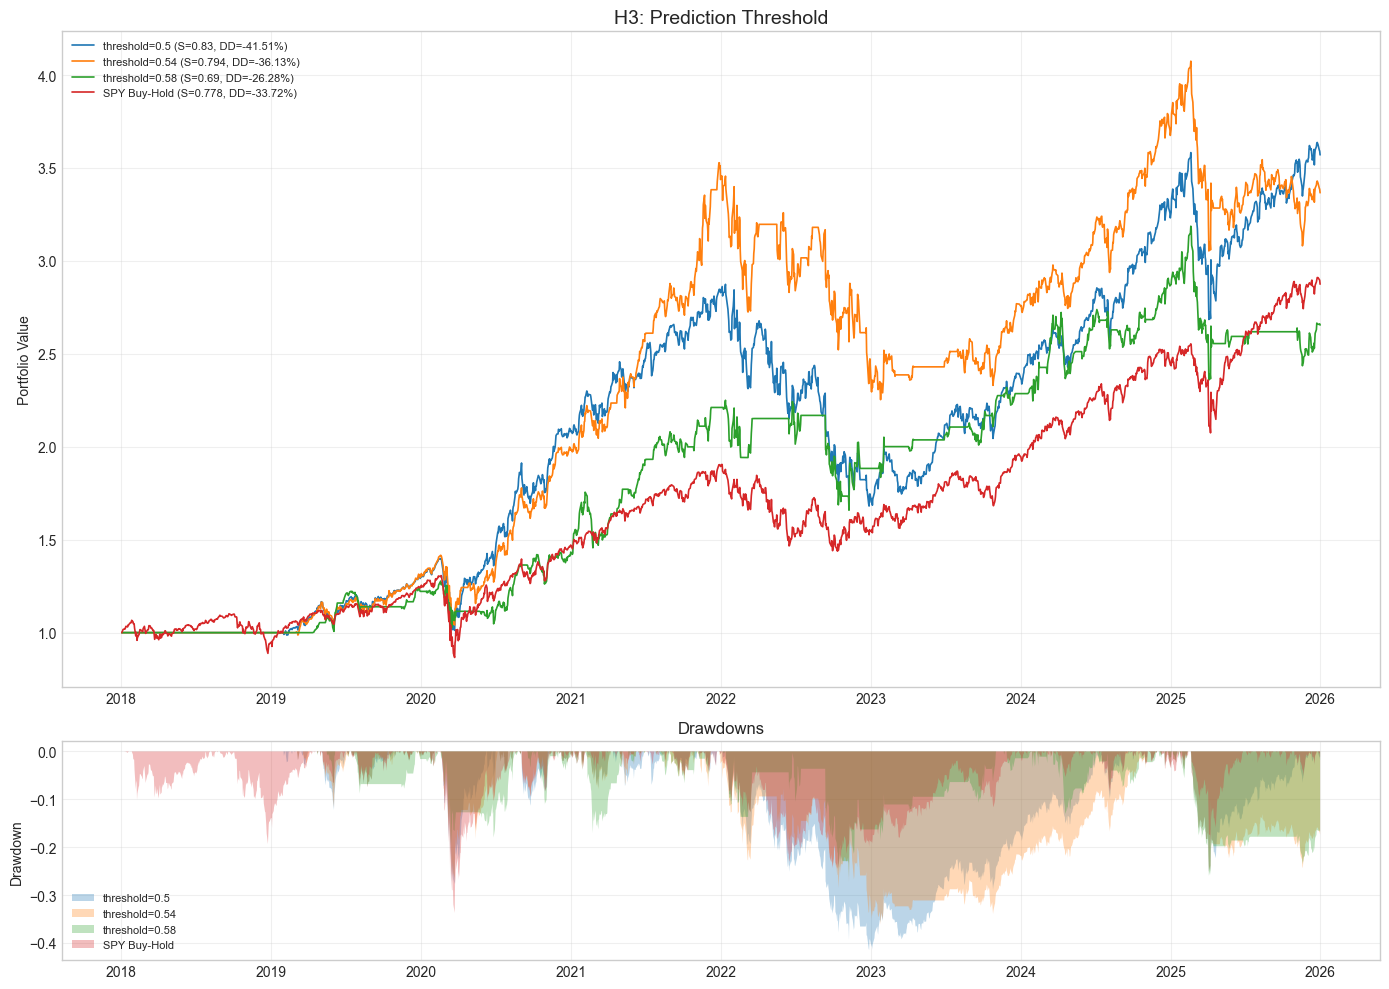

In [7]:
# H3: Prediction threshold
threshold_values = [0.50, 0.54, 0.58]
h3_results = []

for thr in threshold_values:
    print(f"Testing threshold={thr}...")
    r = backtest_rf_strategy(
        prices, TICKERS_10,
        n_estimators=100, max_depth=5, min_samples_split=10,
        threshold=thr, max_positions=5, rebal_weeks=2,
        name=f'threshold={thr}'
    )
    h3_results.append(r)

h3_results.append(benchmark_result)
print("\n=== H3: Prediction Threshold ===")
h3_df = compare_results(h3_results)
plot_equity_curves(h3_results, title='H3: Prediction Threshold')

### Interpretation H3

Le seuil optimal represente le compromis entre selectivite et exposition au marche :
- Si le Sharpe ameliore avec un seuil plus eleve, le modele genere des probabilites bien calibrees.
- Si le Sharpe degrade avec un seuil eleve, le modele n'a pas assez de signaux forts.
- Le CAGR devrait diminuer avec un seuil plus strict (moins de temps investi).

## Hypothese 4 : Taille de l'univers

### Rationale

L'univers d'actions influence la diversification et la qualite des predictions :
- **5 actions** : Moins de bruit mais moins d'opportunites, concentration elevee
- **10 actions (actuel)** : Bonne diversification sectorielle
- **15 actions** : Plus d'opportunites mais le modele doit generaliser sur plus d'actions

Un univers plus large dilue le signal si le modele n'est pas assez expressif.

Testing Universe 5 (5 tickers)...


Testing Universe 10 (10 tickers)...


Testing Universe 15 (15 tickers)...



=== H4: Universe Size ===
              Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                          
Universe 5     1.118     26.74     -35.00    23.78
Universe 10    0.794     16.40     -36.13    22.31
Universe 15    0.840     17.81     -29.21    22.59
SPY Buy-Hold   0.778     14.12     -33.72    19.45

  >> Best Sharpe: Universe 5 (1.118)


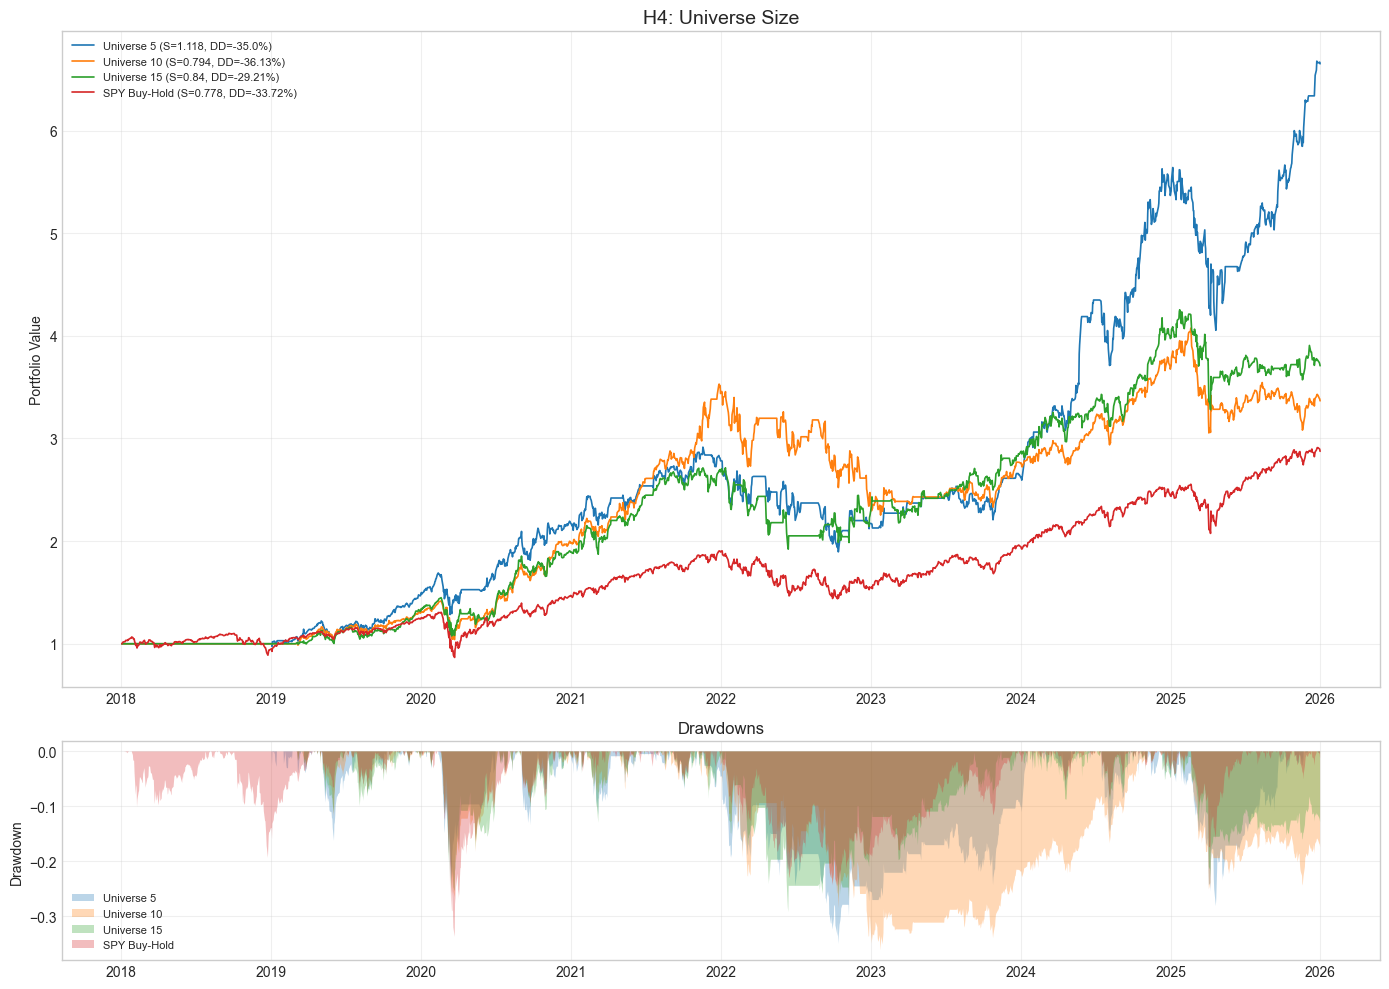

In [8]:
# H4: Universe size
universe_configs = [
    (TICKERS_5, 'Universe 5'),
    (TICKERS_10, 'Universe 10'),
    (TICKERS_15, 'Universe 15'),
]
h4_results = []

for tickers_set, label in universe_configs:
    available = [t for t in tickers_set if t in prices.columns]
    print(f"Testing {label} ({len(available)} tickers)...")
    r = backtest_rf_strategy(
        prices, available,
        n_estimators=100, max_depth=5, min_samples_split=10,
        threshold=0.54, max_positions=5, rebal_weeks=2,
        name=label
    )
    h4_results.append(r)

h4_results.append(benchmark_result)
print("\n=== H4: Universe Size ===")
h4_df = compare_results(h4_results)
plot_equity_curves(h4_results, title='H4: Universe Size')

### Interpretation H4

- Si l'univers 5 performe bien, le modele capte l'essentiel du signal sur les blue chips.
- L'univers 15 est un test de robustesse : si le Sharpe ne degrade pas, le modele generalise bien.
- Le MaxDD devrait etre plus eleve avec un univers plus petit (moins de diversification).

## Hypothese 5 : Frequence d'entrainement

### Rationale

La frequence de re-entrainement du modele determine sa reactivite aux changements de regime :
- **Hebdomadaire** : Modele tres reactif mais risque de sur-ajustement aux conditions recentes
- **Bihebdomadaire** : Compromis entre reactivate et stabilite
- **Mensuel (actuel)** : Stable mais peut rater les changements de regime rapides

Les marches changent de regime plus frequemment en periode de volatilite elevee (2020, 2022).

Testing Weekly rebal...


Testing Biweekly rebal (current)...


Testing Monthly rebal...



=== H5: Rebalancing Frequency ===
                          Sharpe  CAGR (%)  MaxDD (%)  Vol (%)
Strategy                                                      
Weekly rebal               0.495      8.61     -40.74    21.37
Biweekly rebal (current)   0.794     16.40     -36.13    22.31
Monthly rebal              0.919     19.59     -30.35    22.21
SPY Buy-Hold               0.778     14.12     -33.72    19.45

  >> Best Sharpe: Monthly rebal (0.919)


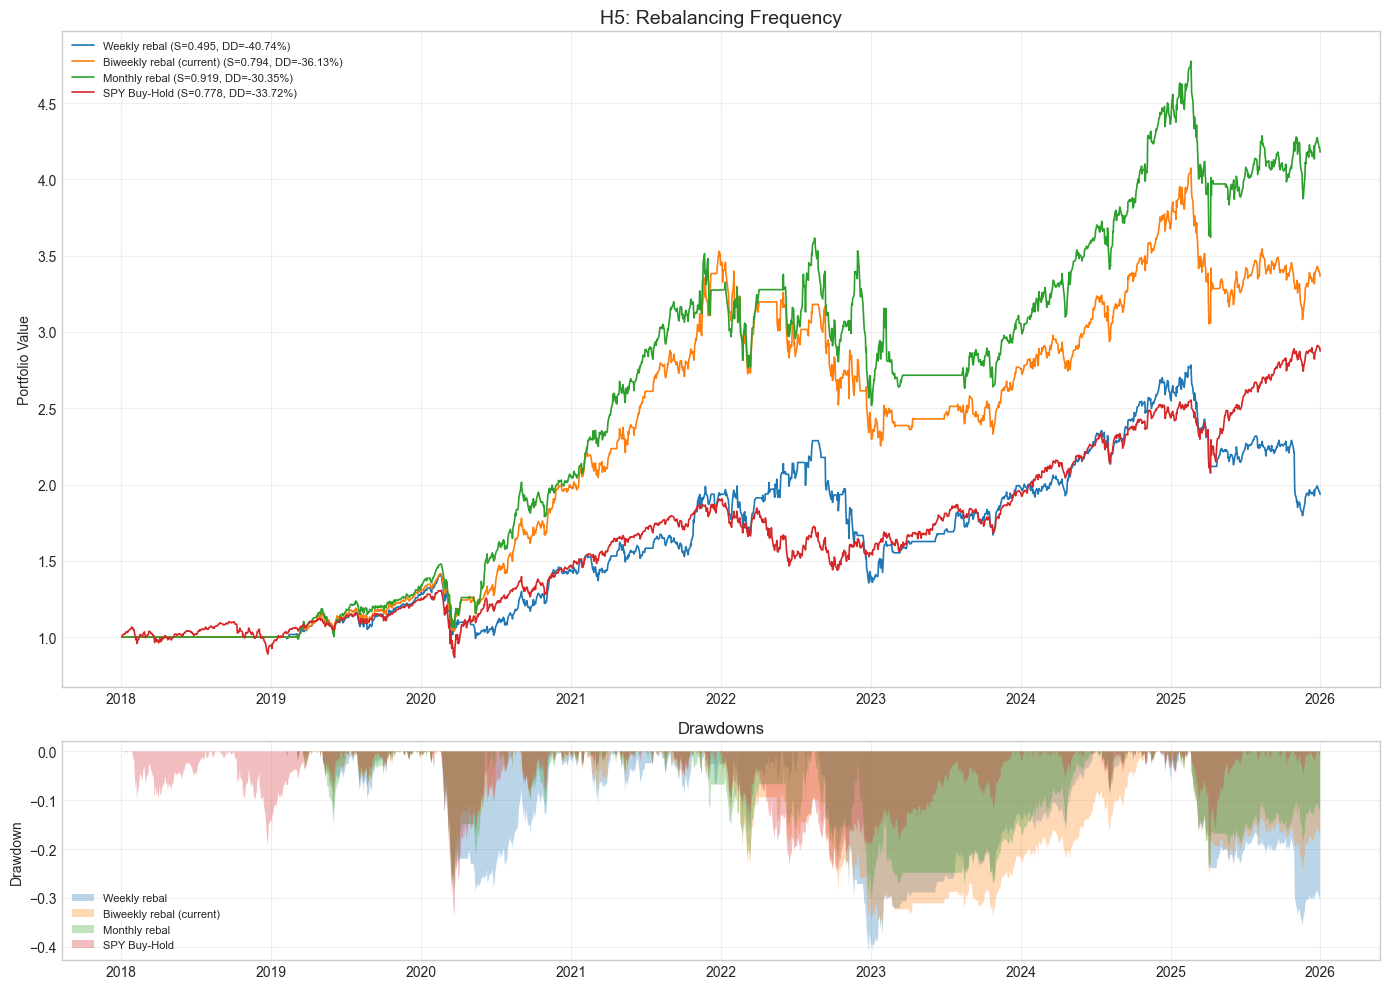

In [9]:
# H5: Training frequency (simulated via rebalance + train interval)
# We vary the rebalancing frequency while keeping monthly training
rebal_configs = [
    (1, 'Weekly rebal'),
    (2, 'Biweekly rebal (current)'),
    (4, 'Monthly rebal'),
]
h5_results = []

for rebal_w, label in rebal_configs:
    print(f"Testing {label}...")
    r = backtest_rf_strategy(
        prices, TICKERS_10,
        n_estimators=100, max_depth=5, min_samples_split=10,
        threshold=0.54, max_positions=5, rebal_weeks=rebal_w,
        name=label
    )
    h5_results.append(r)

h5_results.append(benchmark_result)
print("\n=== H5: Rebalancing Frequency ===")
h5_df = compare_results(h5_results)
plot_equity_curves(h5_results, title='H5: Rebalancing Frequency')

### Interpretation H5

- Un rebalancement hebdomadaire devrait augmenter le CAGR si le signal est fort,
  mais aussi augmenter les couts de transaction (non modelises ici).
- Le rebalancement mensuel est plus economique mais peut laisser des positions obsoletes.
- Le bihebdomadaire (actuel) est un compromis reasonable.

## Synthese : Analyse de l'importance des features

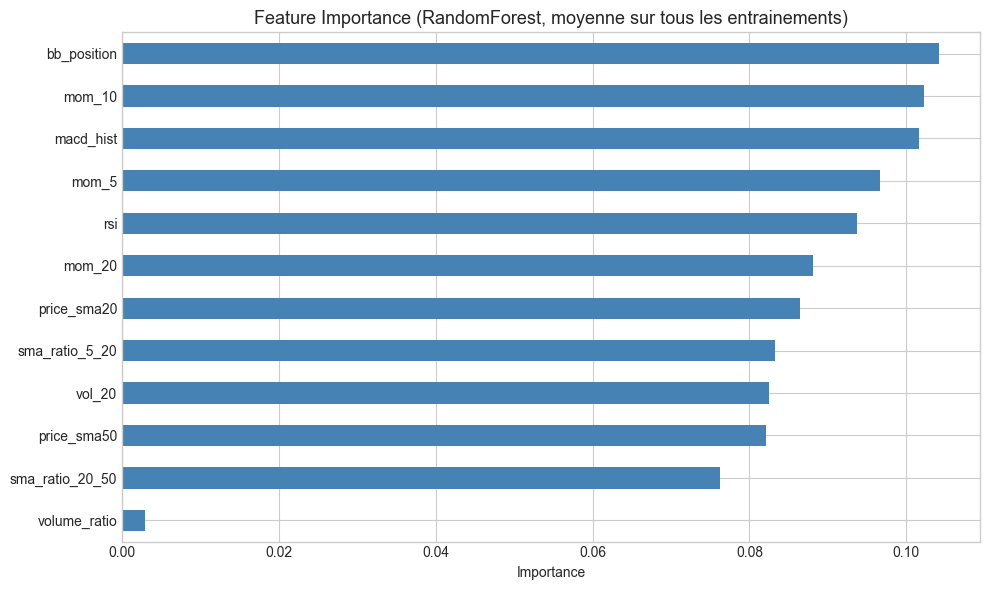


Feature importance ranking:
  bb_position         : 0.1042
  mom_10              : 0.1023
  macd_hist           : 0.1016
  mom_5               : 0.0966
  rsi                 : 0.0937
  mom_20              : 0.0881
  price_sma20         : 0.0864
  sma_ratio_5_20      : 0.0832
  vol_20              : 0.0825
  price_sma50         : 0.0821
  sma_ratio_20_50     : 0.0763
  volume_ratio        : 0.0029


In [10]:
# Feature importance: reuse H1 result with n_estimators=100 (same config as baseline)
baseline = next((r for r in h1_results if r and r.get('name') == 'n_est=100'), None)

if baseline is None:
    print("H1 n_est=100 not found, running baseline...")
    baseline = backtest_rf_strategy(
        prices, TICKERS_10,
        n_estimators=100, max_depth=5, min_samples_split=10,
        threshold=0.54, max_positions=5, rebal_weeks=2,
        name='Baseline'
    )

if baseline and baseline.get('feature_importance'):
    imp = pd.Series(baseline['feature_importance']).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Feature Importance (RandomForest, moyenne sur tous les entrainements)', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print("\nFeature importance ranking:")
    for feat, val in imp.sort_values(ascending=False).items():
        print(f"  {feat:20s}: {val:.4f}")
else:
    print("Baseline backtest did not produce feature importance.")

## Conclusions et recommandations

### Configuration recommandee pour main.py

Basee sur les resultats des hypotheses, remplir le tableau ci-dessous apres execution :

| Parametre | Valeur actuelle | Valeur recommandee | Justification |
|-----------|----------------|--------------------|--------------|
| n_estimators | 100 | A determiner | Resultat H1 |
| max_depth | 5 | A determiner | Resultat H2 |
| threshold | 0.54 | A determiner | Resultat H3 |
| Universe | 10 tickers | A determiner | Resultat H4 |
| Rebalancing | Biweekly | A determiner | Resultat H5 |

### Limites de cette analyse

- **Pas de frais de transaction** : Le backtest standalone ne modelise pas les commissions QC
- **Donnees ajustees uniquement** : yfinance fournit des prix ajustes, pas les prix reels de execution
- **High/Low approximes** : Les features utilisent close comme approximation de high/low
- **Look-ahead risque** : Les meilleurs parametres sont choisis sur l'echantillon complet
- **Periode unique** : 2015-2026, un walk-forward sur plusieurs sous-periodes serait plus robuste

### Prochaines etapes

1. Implementer les parametres recommandes dans `main.py`
2. Backtester sur QC Cloud pour valider avec les couts reels
3. Comparer le Sharpe standalone vs Sharpe QC pour estimer l'impact des frais
4. Considerer un walk-forward test sur 3 sous-periodes (2015-2018, 2018-2022, 2022-2026)